<a href="https://colab.research.google.com/github/Chandithya/Abc/blob/main/Chandithya_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Introduction

Linear Regression

N chandithya

Car dataset

https://drive.google.com/file/d/15b-pu_vtyts0WnwCfnvRC3YyVvG3k5fm/view?usp=drive_link

The above dataset is about cars like car brand,kilometers driven ,transmission


The main goal of this project is to analyze,understand,visualize and clean datset like missing , duplicated, extra spaces values etc the main aspect of this analysis is to have clean and clear dataset and do the linear regression

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

sns.set_theme(style='whitegrid')

In [ ]:
# Choose the used-cars CSV file from your computer

from google.colab import files

uploaded = files.upload()

csv_file = next(iter(uploaded))

df = pd.read_csv(csv_file)

print('Shape:', df.shape)

df.head()

Saving car data.csv to car data (1).csv
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f'\n{column}:')
    print(df[column].value_counts())


Car_Name:
Car_Name
city                  26
corolla altis         16
verna                 14
brio                  10
fortuner              10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64

Fuel_Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller_Type:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(include = "number")
print(numeric_cols)

     Year  Selling_Price  Present_Price  Kms_Driven  Owner
0    2014           3.35           5.59       27000      0
1    2013           4.75           9.54       43000      0
2    2017           7.25           9.85        6900      0
3    2011           2.85           4.15        5200      0
4    2014           4.60           6.87       42450      0
..    ...            ...            ...         ...    ...
296  2016           9.50          11.60       33988      0
297  2015           4.00           5.90       60000      0
298  2009           3.35          11.00       87934      0
299  2017          11.50          12.50        9000      0
300  2016           5.30           5.90        5464      0

[299 rows x 5 columns]


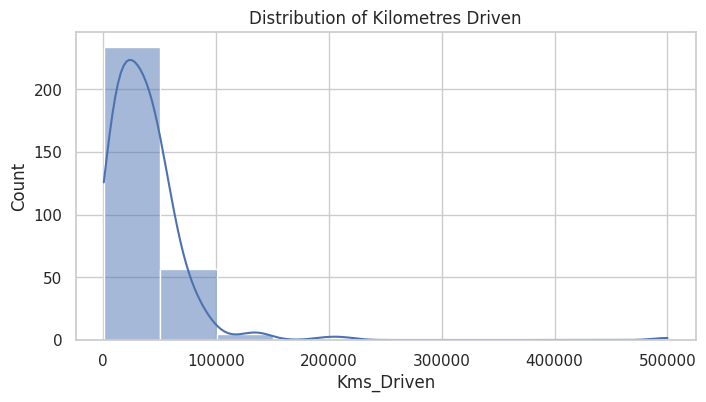

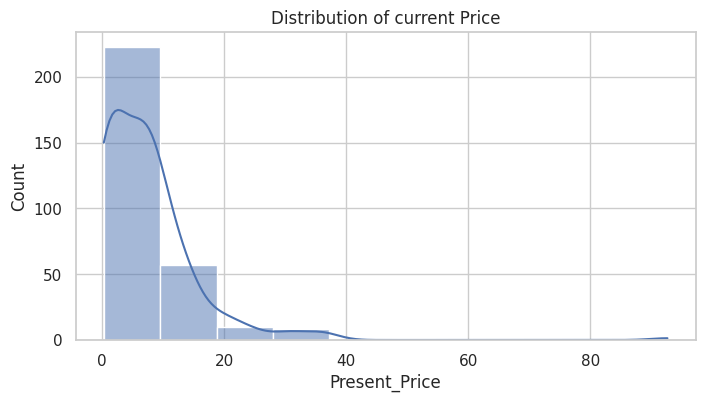

In [ ]:
#Univariaye analysis
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Kms_Driven', bins=10, kde=True)
plt.title('Distribution of Kilometres Driven')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Present_Price', bins=10, kde=True)
plt.title('Distribution of current Price')
plt.show()

This is a chart of KIlometers driven

*   Most cars kilometers driven is between 0 to 50000
*   Few cars have driven around 100000km



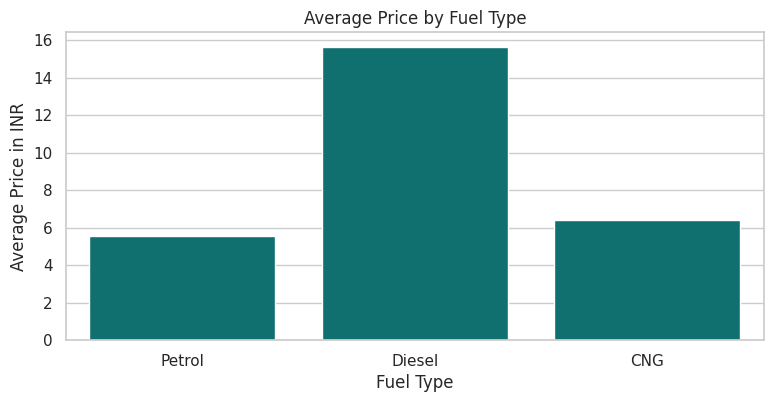

In [ ]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=df,
    x='Fuel_Type',
    y='Present_Price',
    errorbar=None,
    color='teal'
)
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price in INR')
plt.show()



*   The present price of the diesel is more compared to others
*   By this we can conclude that diesel demand is more



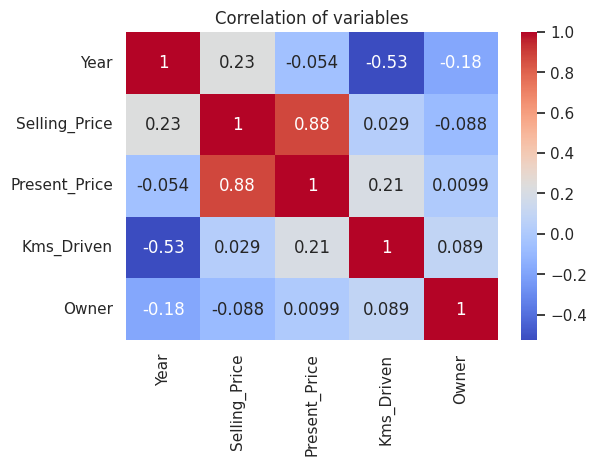

In [ ]:
#Multivariate analysis
corr = df.corr(numeric_only = True)
plt.figure(figsize= (6,4))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation of variables")
plt.show()

This is the heatmap

*   Cars with higher showroom prices tend to have higher resale values. This is the most important relationship in the dataset.
*   Newer cars (higher year) sell for slightly more, but the effect is not very strong compared to Present Price.
*   Older cars tend to have higher mileage. This makes sense: the longer a car has been around, the more it’s driven.
*    The number of previous owners doesn’t strongly affect resale price in this dataset, though in practice it might influence buyer perception.





In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Seller_Type    299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


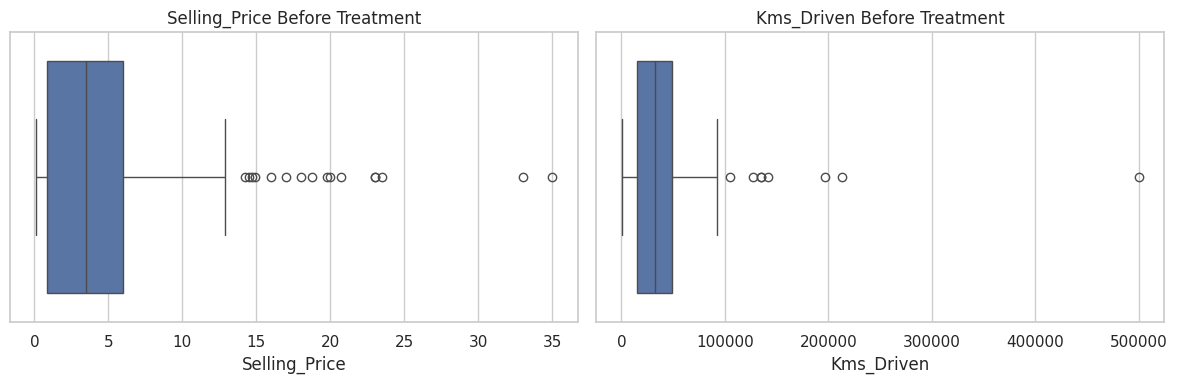

In [ ]:
outlier_columns = ['Selling_Price', 'Kms_Driven']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, column in zip(axes, outlier_columns):
    sns.boxplot(x=df[column], ax=axis)
    axis.set_title(f'{column} Before Treatment')
plt.tight_layout()
plt.show()

In [ ]:
# Build one combined mask, then filter only once
keep_rows = pd.Series(True, index=df.index)

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column_mask = df[column].between(
        lower_bound, upper_bound
    )
    print(f'{column}: {(~column_mask).sum()} outlier(s)')
    keep_rows &= column_mask

df = df.loc[keep_rows].reset_index(drop=True)
print('Shape after outlier removal:', df.shape)

Selling_Price: 16 outlier(s)
Kms_Driven: 8 outlier(s)
Shape after outlier removal: (277, 9)


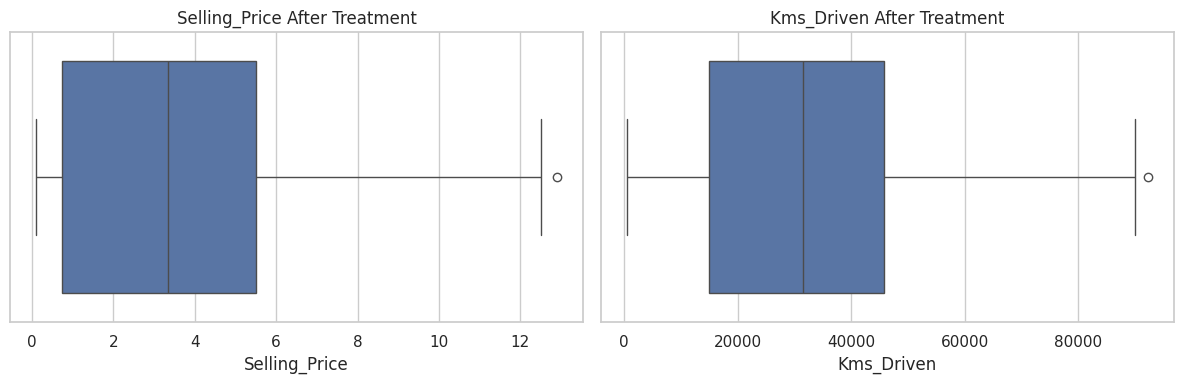

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, column in zip(axes, outlier_columns):
    sns.boxplot(x=df[column], ax=axis)
    axis.set_title(f'{column} After Treatment')
plt.tight_layout()
plt.show()

In [ ]:
df["Transmission"].value_counts()

,count
Transmission,
Manual,253
Automatic,24


In [ ]:
df["Transmission"] = (df["Transmission"].map({"Manual":1,"Automatic":0}))

In [ ]:
df["Seller_Type"].value_counts()

,count
Seller_Type,
Dealer,176
Individual,101


In [ ]:
df["Seller_Type"] = (df["Seller_Type"].map({"Dealer":1,"Individual":0}))

In [ ]:
df["Fuel_Type"].value_counts()

,count
Fuel_Type,
Petrol,231
Diesel,44
CNG,2


In [ ]:
df["Fuel_Type"] = (df["Fuel_Type"].map({"Petrol":1,"Diesel":0,"CNG":2}))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       277 non-null    object 
 1   Year           277 non-null    int64  
 2   Selling_Price  277 non-null    float64
 3   Present_Price  277 non-null    float64
 4   Kms_Driven     277 non-null    int64  
 5   Fuel_Type      277 non-null    int64  
 6   Seller_Type    277 non-null    int64  
 7   Transmission   277 non-null    int64  
 8   Owner          277 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 19.6+ KB


In [ ]:
#converting categorical columns to numerical columns using One-Hot encoding
categorical_columns = df.select_dtypes(include='object').columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Columns: 101 entries, Year to Car_Name_xcent
dtypes: float64(2), int64(99)
memory usage: 218.7 KB


Insights

*   Most cars kilometers driven is between 0 to 100000
*   Diesel cars often retain value longer compared to petrol cars
*   demand for CNG cars are less compared to diesel and petrol cars
*   Demand for the manual cars are more
*   Detected outliers and remove them
*   Removed the duplicated values







In [ ]:
# X & y  separation
x = df.drop(columns = ["Present_Price"])
y = df["Present_Price"]

In [ ]:
x.head()

,Year,Selling_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,...,Car_Name_jazz,Car_Name_omni,Car_Name_ritz,Car_Name_s cross,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent
0,2014,3.35,27000,1,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,2013,4.75,43000,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,2017,7.25,6900,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2011,2.85,5200,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2014,4.60,42450,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
y.head()

,Present_Price
0,5.59
1,9.54
2,9.85
3,4.15
4,6.87


In [ ]:
#splitting Data into trianing and testing parts
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((221, 100), (56, 100), (221,), (56,))

In [ ]:
#Performing the feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
#Importing the linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
#Training the model to make predictions
y_pred = model.predict(x_test)
y_pred

array([ 5.61144045,  2.31370015,  9.18900919,  0.39881274, 10.78029573,
       12.23027218,  2.03688471,  4.37804015,  6.07807881,  0.32288311,
        0.59316065, 15.17377706, 10.49075771,  2.11662728, 12.12246416,
        0.74022889,  4.32552892, 18.59587796,  5.97584388,  8.10322557,
        4.80511411, 11.5846757 ,  5.28997657,  0.56141188, 10.41184756,
        4.24415646,  0.9174424 ,  2.96453024,  9.8430435 ,  1.00955681,
        3.95339396,  0.82653132,  6.61594932,  1.9549237 ,  6.81946754,
       17.92828734, 12.13237163,  7.81358389,  9.43025435, 17.72095135,
        9.08627165,  2.7232227 ,  4.24277016,  7.57456238,  1.62418166,
       13.59121615,  3.53464068,  1.01429233, 12.06319631,  9.41627679,
        0.83018485,  0.609912  ,  5.17241805, 10.07365211, -0.69514505,
        2.45150015])

In [ ]:
#comparing the actual and predicted data
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
30,4.89,5.611440
126,0.94,2.313700
220,9.40,9.189009
142,0.54,0.398813
255,13.60,10.780296
236,13.60,12.230272
97,1.90,2.036885
215,4.43,4.378040
256,5.90,6.078079
144,0.55,0.322883


In [ ]:
#calculating the errors using mse
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 1.5524188373485792
Mean Absolute Error: 0.8949549473092568
R-squared: 0.9387245975537689


In [ ]:
import pandas as pd

# Get the column names from the training data (x)
expected_columns = x.columns

new_data = pd.DataFrame(0, index=[0], columns=expected_columns)
new_data_scaled = scaler.transform(new_data)
predicted_selling_price = model.predict(new_data_scaled)
print("Predicted Selling Price:", predicted_selling_price[0])

Predicted Selling Price: 352.7262651061184


In [ ]:
print("coeffiecents:",model.coef_)
print("intercept:",model.intercept_)

coeffiecents: [-4.68916851e-01  2.06695828e+00  3.12228060e-01  1.62145230e-01
  5.17319952e-01 -1.89247731e-01 -3.57578500e-02  1.11992575e-02
 -6.72228503e-03  3.96574860e-02  3.33238540e-02  1.05232044e-01
  5.44407785e-03 -1.25812555e-02 -1.00797201e-02 -1.82445818e-02
  7.91421954e-02  1.75188740e-02  1.45545117e-02 -7.67723422e-03
  4.27645364e-02  7.04237614e-03  5.82065880e-02 -7.37082848e-02
  1.49964369e-02  1.07687232e-02  5.55111512e-17 -7.19394366e-02
 -5.99674948e-02 -7.40803385e-02  2.73455970e-02  9.96187757e-03
 -4.86731332e-03  1.92884365e-02 -1.28577988e-01 -5.55111512e-17
  7.56370532e-03  8.79416904e-02 -9.87482840e-02  9.65666126e-03
  4.16333634e-17 -4.75490255e-02  1.38777878e-17  4.46128766e-02
 -7.39409871e-03 -1.38777878e-17 -1.06895558e-17  1.16605004e-01
  9.11276006e-02  3.34110939e-02  5.18627106e-02  9.18267364e-02
  1.67490535e-02  7.78151840e-02  1.06394475e-01 -8.36307908e-02
  2.08046933e-02  7.33049597e-03 -3.90118157e-02  3.67951711e-02
 -8.4496608

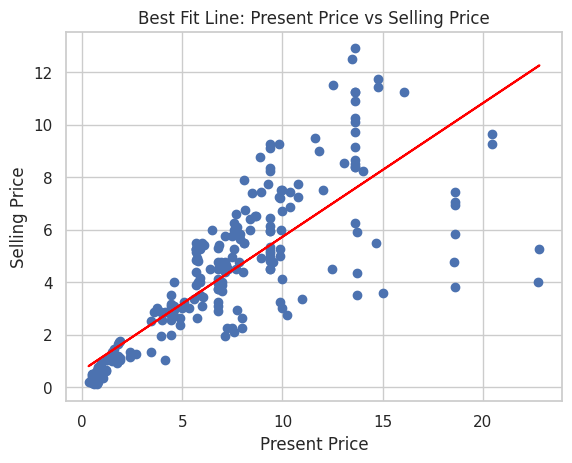

In [ ]:
import numpy as np

# Best fit line for Present_Price vs Selling_Price
plt.scatter(df['Present_Price'], df['Selling_Price'])
m, c = np.polyfit(df['Present_Price'], df['Selling_Price'], 1)
plt.plot(df['Present_Price'], m*df['Present_Price'] + c, color='red')

plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.title('Best Fit Line: Present Price vs Selling Price')
plt.show()